# Notebook 09 — Forecasting Offered Air Seats at Polish Airports from Macroeconomic Inputs

## Macro-Aviation-Tourism Demand Modelling and Forecasting for Poland
 
**Author:** Diego Marrero Ferrera (ULPGC, Grado en Ciencia e Ingeniería de Datos - Data Science and Engineering)  

**Repository:** [GitHub -- Macro-Aviation-Tourism-Modeling](https://github.com/DieGodMF4/Macro-Aviation-Tourism-Modeling)  

---


## Purpose

Notebooks NB00–NB08 forecast **foreign overnight stays** in Poland (Eurostat `tour_occ_nim`) from a panel of 9 origin markets. This deliverable inverts the target. The dependent variable here is **Passengers seats available** at Polish airports (Eurostat `avia_tf_aca`), aggregated across the 13 Polish commercial airports.

The operational question is different from the rest of the TFG. Seats are not a demand outcome — they are an **airline supply decision**, made by capacity planners several months before flights operate. Annual schedules at Polish airports are typically finalised around 12 months in advance: IATA slot conferences run twice a year, route launches and fleet positioning have lead times of 9–18 months, and ticket-selling windows open about a year before operation. The model in this notebook reflects that institutional reality. It forecasts seats in month `t` from the **macroeconomic signals available to airline planners 12 months earlier** (at `t − 12`).

Two models are estimated in parallel on the same target and the same hold-out window:

| Model | Family | Goal |
|---|---|---|
| **A** | OLS, single elasticity in YoY log-differences | Interpretable formula |
| **B** | XGBoost with a richer lagged feature set | Sanity check on whether non-linearity buys precision |

Both predict $\Delta\log(\text{seats}_t) = \log(\text{seats}_t) - \log(\text{seats}_{t-12})$. Level forecasts are recovered as $\widehat{\text{seats}}_t = \text{seats}_{t-12} \cdot \exp(\widehat{\Delta\log\,\text{seats}_t})$.

## Methodological choices

- Random seed `2004` (year of Poland's EU accession).
- **COVID-strong window: Jan 2020 – Dec 2021** (24 months). Inspection of the seats series shows that summer 2022 was already at or above pre-COVID seasonal levels, so 2022 is treated as recovery and kept in training.
- **Aggregate origin-market GDP** is used, not GDP per capita. Seats are a raw count, so the relevant macro driver is also a raw aggregate. Constructed as `gdp_total = gdp_pc × population`.
- **Single regressor at lag 9** in Model A. Multi-regressor specifications (price, sentiment) raise in-sample R² but overfit and degrade hold-out accuracy on a sample of ~100 clean observations.
- Standard errors: Newey–West HAC with lag 12 to handle the overlap induced by YoY differences on monthly data.

## 1. Setup

In [2]:
import os
import pandas as pd
import numpy as np
import statsmodels.api as sm
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

SEED = 2004
np.random.seed(SEED)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook', font_scale=1.1)
plt.rcParams.update({
    'figure.figsize': (12, 6), 'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.labelsize': 11, 'font.size': 10, 'legend.fontsize': 9,
    'axes.spines.top': True, 'axes.spines.right': True,
    'axes.grid': True, 'grid.alpha': 0.4, 'grid.linestyle': '--',
    'lines.linewidth': 2.0,
    'savefig.bbox': 'tight', 'savefig.dpi': 200, 'savefig.facecolor': 'white',
})

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)

DATA_PROCESSED = os.path.join('..', 'data', 'processed')
DATA_RAW_TRANSPORT = os.path.join('..', 'data', 'raw')
FIG_DIR        = os.path.join('..', 'figures', 'models')
os.makedirs(FIG_DIR, exist_ok=True)

def savefig(name):
    plt.savefig(os.path.join(FIG_DIR, name), dpi=200, bbox_inches='tight')

PATH_PANEL    = f'{DATA_PROCESSED}/master_panel_monthly.csv'
PATH_AVIA_TF  = f'{DATA_RAW_TRANSPORT}/transport/avia_tf_aca__seats-flights-pass-PL-2010-.csv'
PATH_AVIA_PAOC= f'{DATA_RAW_TRANSPORT}/transport/avia_paoc__passengers-countries.csv'

plt.rcParams.update({'figure.figsize': (10,4), 'axes.grid': True, 'grid.alpha': 0.3})

## 2. Data

Three inputs:

1. **`master_panel_monthly.csv`** — the panel built in NB02. Monthly, 2011-01 to 2025-11, with origin-weighted macro aggregates and Polish-side controls. The variable `seats` is the total of *Passengers seats available* across the 13 Polish airports.
2. **`avia_tf_aca`** — disaggregated by airport. Used only for the descriptive decomposition; the panel `seats` total has been verified to equal the sum across airports exactly.
3. **`avia_paoc`** — passengers on board by origin country. Used for descriptive decomposition of origin markets. (UK is unavailable post-Brexit; the panel uses ONS data chain-linked, per NB02.)

In [3]:
mp = pd.read_csv(PATH_PANEL, parse_dates=['date']).sort_values('date').reset_index(drop=True)
print(f"Panel: {len(mp)} rows, range {mp['date'].min().date()} -> {mp['date'].max().date()}")
print(f"Target (seats) available through:           {mp.dropna(subset=['seats'])['date'].max().date()}")
print(f"Macro vars (gdp_pc, pop) available through: {mp.dropna(subset=['gdp_pc_origins_wavg'])['date'].max().date()}")

Panel: 179 rows, range 2011-01-01 -> 2025-11-01
Target (seats) available through:           2025-10-01
Macro vars (gdp_pc, pop) available through: 2025-01-01


## 3. Descriptive context

### 3.1 Total seats and the structural growth of Polish aviation

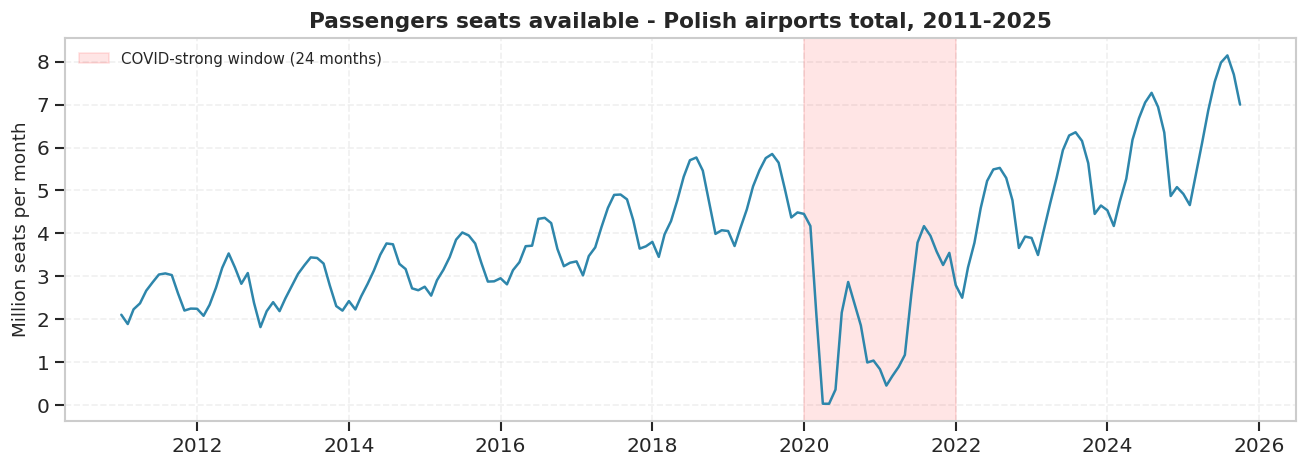

Total seats grew from 2.11M (Jan 2011) to peak 8.15M.
That is roughly a 3.9x expansion over 14 years.


In [4]:
fig, ax = plt.subplots(figsize=(11,4))
ax.plot(mp['date'], mp['seats']/1e6, color='#2E86AB', linewidth=1.5)
ax.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2021-12-31'), color='red', alpha=0.10, label='COVID-strong window (24 months)')
ax.set_ylabel('Million seats per month')
ax.set_title('Passengers seats available - Polish airports total, 2011-2025')
ax.legend(loc='upper left')
plt.tight_layout()
savefig('09_01_seats_trend_evolution.png')
plt.show()

print(f"Total seats grew from {mp['seats'].iloc[0]/1e6:.2f}M (Jan 2011) to peak {mp['seats'].max()/1e6:.2f}M.")
print(f"That is roughly a {mp['seats'].max()/mp['seats'].iloc[0]:.1f}x expansion over 14 years.")

Three features of the series shape the modelling strategy:

1. **A strong secular trend** — seats nearly quadrupled in 14 years. The driver is supply-side (LCC base openings, fleet expansion), not contemporaneous macroeconomic conditions in origin markets.
2. **A clear annual seasonality** that is preserved across the COVID shock — summer peaks, winter troughs. The YoY differencing used below removes this seasonality by construction (each month is compared to the same calendar month one year earlier).
3. **A sharp COVID dislocation in 2020–2021** followed by recovery already in place by summer 2022. The COVID-strong window is therefore defined as `[2020-01, 2021-12]` (24 months) rather than the full three-year span sometimes used in the literature.

### 3.2 Composition of the total — airports

The seats total is dominated by Warsaw Chopin (~37% of 2024 capacity), with Krakow, Gdansk, and Katowice making up most of the rest.

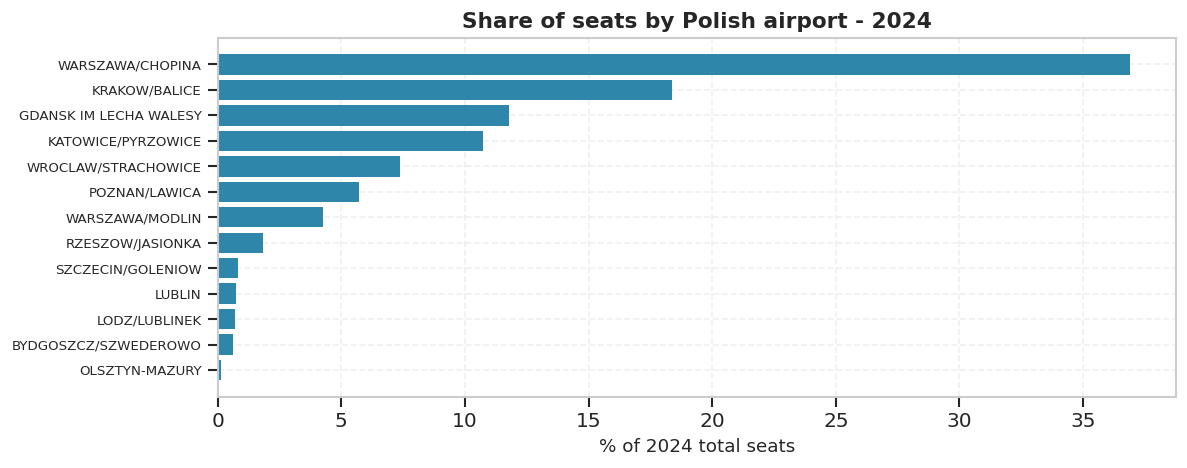

Max abs discrepancy between panel `seats` and airport sum: 0.0


In [5]:
ta = pd.read_csv(PATH_AVIA_TF)
ta = ta[ta['tra_meas']=='Passengers seats available'].copy()
ta['date'] = pd.to_datetime(ta['TIME_PERIOD'])

share_2024 = (ta[ta['date'].dt.year==2024].groupby('rep_airp')['OBS_VALUE'].sum()
              .sort_values(ascending=False))
share_2024_pct = share_2024 / share_2024.sum() * 100

fig, ax = plt.subplots(figsize=(10,4))
ax.barh(range(len(share_2024_pct)), share_2024_pct.values[::-1], color='#2E86AB')
ax.set_yticks(range(len(share_2024_pct)))
ax.set_yticklabels([a.replace(' airport','') for a in share_2024_pct.index[::-1]], fontsize=8)
ax.set_xlabel('% of 2024 total seats')
ax.set_title('Share of seats by Polish airport - 2024')
plt.tight_layout()
savefig('09_02_seats_share_airports.png')
plt.show()

agg = ta.groupby('date')['OBS_VALUE'].sum().rename('seats_from_airports').reset_index()
chk = mp[['date','seats']].merge(agg, on='date', how='inner')
print(f"Max abs discrepancy between panel `seats` and airport sum: {(chk['seats']-chk['seats_from_airports']).abs().max():.1f}")

### 3.3 Composition of the total — origin markets

Aggregating passenger flows on board over 2024 across the 9 origin emitters used in the TFG panel:

> Note: Eurostat's `avia_paoc` does not publish the United Kingdom after Brexit. The panel uses ONS data chain-linked from the EU break, as documented in NB02.

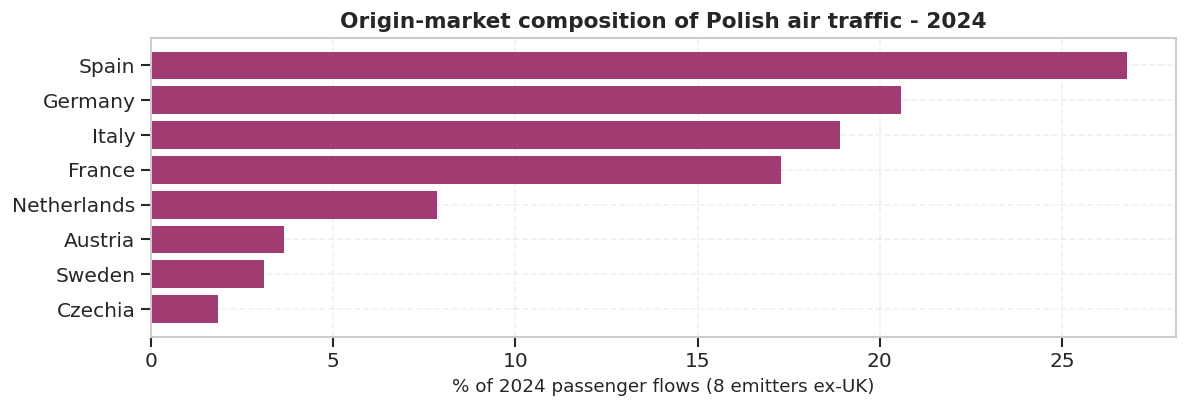

In [6]:
pc = pd.read_csv(PATH_AVIA_PAOC)
pc['date'] = pd.to_datetime(pc['TIME_PERIOD'])
emitters_8 = ['Spain','Germany','Italy','France','Netherlands','Austria','Sweden','Czechia']
share_origins = (pc[(pc['date'].dt.year==2024) & (pc['geo'].isin(emitters_8))]
                 .groupby('geo')['OBS_VALUE'].sum().sort_values(ascending=False))
share_origins_pct = share_origins / share_origins.sum() * 100

fig, ax = plt.subplots(figsize=(10,3.5))
ax.barh(range(len(share_origins_pct)), share_origins_pct.values[::-1], color='#A23B72')
ax.set_yticks(range(len(share_origins_pct)))
ax.set_yticklabels(share_origins_pct.index[::-1])
ax.set_xlabel('% of 2024 passenger flows (8 emitters ex-UK)')
ax.set_title('Origin-market composition of Polish air traffic - 2024')
plt.tight_layout()
savefig('09_03_seats_origin_market.png')
plt.show()

## 4. Feature engineering

### 4.1 Building the aggregate GDP variable

Seats are a raw count of airline capacity. The corresponding macroeconomic driver is **aggregate GDP in origin markets**, not GDP per capita. We construct it as:

$$ \text{gdp\_total}_t \;=\; \text{gdp\_pc}_t \times \text{population}_t $$

Both inputs are the origin-weighted aggregates from the TFG panel (NB02 weights from air-passenger shares).

In [7]:
mp['gdp_total_origins'] = mp['gdp_pc_origins_wavg'] * mp['pop_origins_wavg']
print(f"Aggregate origin GDP available through: {mp.dropna(subset=['gdp_total_origins'])['date'].max().date()}")
print(f"Range: {mp['gdp_total_origins'].min()/1e9:.1f}B to {mp['gdp_total_origins'].max()/1e9:.1f}B (PPP-adjusted units, weighted)")

Aggregate origin GDP available through: 2025-01-01
Range: 393.2B to 490.1B (PPP-adjusted units, weighted)


### 4.2 YoY log-differences

We work in **year-on-year log differences** to remove the secular trend and the seasonal cycle simultaneously. For any positive series $X_t$,
$$ \Delta\log X_t \;\equiv\; \log X_t - \log X_{t-12} \;\approx\; \text{YoY growth rate of } X. $$

The same transformation is applied to the target and to macro regressors. For the consumer-confidence indicator (a centered index that can be negative) we use the 12-month difference in levels.

In [8]:
def yoy_logdiff(s):
    return np.log(s) - np.log(s.shift(12))

mp['dlog_seats']         = yoy_logdiff(mp['seats'])
mp['dlog_gdp_total']     = yoy_logdiff(mp['gdp_total_origins'])
mp['dlog_gdp_pc']        = yoy_logdiff(mp['gdp_pc_origins_wavg'])
mp['dlog_relprice']      = yoy_logdiff(mp['relprice_wavg'])
mp['dlog_exr_pln']       = yoy_logdiff(mp['exr_pln'])
mp['dlog_hicp_PL']       = yoy_logdiff(mp['hicp_PL'])
mp['dlog_hicp_origins']  = yoy_logdiff(mp['hicp_origins_wavg'])
mp['dcci_origins']       = mp['cci_origins_wavg_noUK'] - mp['cci_origins_wavg_noUK'].shift(12)

# Lags at 6, 9, 12 months (airline planning horizons)
for c in ['dlog_gdp_total','dlog_relprice','dcci_origins',
          'dlog_exr_pln','dlog_hicp_PL','dlog_hicp_origins']:
    for L in [6, 9, 12]:
        mp[f'{c}_lag{L}'] = mp[c].shift(L)

# Lag of target itself (for XGBoost; NoLag1 principle: lag >= 6 only)
mp['dlog_seats_lag6']  = mp['dlog_seats'].shift(6)
mp['dlog_seats_lag12'] = mp['dlog_seats'].shift(12)

print(f"Feature engineering complete.")

Feature engineering complete.


### 4.3 COVID exclusion window

The strong-COVID window is `[2020-01, 2021-12]`. A row is excluded from training if **any of its YoY components** falls in that window, because the YoY difference is then mechanically distorted:

| Component | Distorted when |
|---|---|
| `dlog_seats(t)` | `t` or `t − 12` in COVID-strong |
| `dlog_gdp_total(t − 12)` | `t − 12` or `t − 24` in COVID-strong |

The union of these conditions excludes `t` in `[2020-01, 2023-12]` — 48 months — from training. The resulting clean sample preserves the entire pre-COVID period (2011–2019) plus the post-recovery period from January 2024 onwards.

In [9]:
covid_strong = ((mp['date']>=pd.Timestamp('2020-01-01')) &
                (mp['date']<=pd.Timestamp('2021-12-01'))).astype(int)

# A row's YoY-at-lag-12 inputs are clean iff none of {t, t-12, t-24} is in COVID-strong
covid_lhs_dirty = ((covid_strong==1) | (covid_strong.shift(12).fillna(0)==1)).astype(int)
covid_rhs_dirty = ((covid_strong.shift(12).fillna(0)==1) | (covid_strong.shift(24).fillna(0)==1)).astype(int)
mp['covid_excl'] = ((covid_lhs_dirty==1) | (covid_rhs_dirty==1)).astype(int)

print(f"Rows with covid_excl=1: {mp['covid_excl'].sum()}")
print(f"COVID-excluded range:   {mp.loc[mp['covid_excl']==1,'date'].min().date()} → {mp.loc[mp['covid_excl']==1,'date'].max().date()}")

Rows with covid_excl=1: 48
COVID-excluded range:   2020-01-01 → 2023-12-01


## 5. Train/test split

Using lagged macro inputs has an additional benefit: the **hold-out can extend to the latest seats observation** (October 2025), because the macro input needed for `t = 2025-10` is `dlog_gdp_total(2024-10)` — comfortably available in the panel (macro data ends January 2025). With contemporaneous macro the hold-out would have ended at January 2025.

- **Hold-out:** the last 12 consecutive months with both `dlog_seats(t)` and `dlog_gdp_total(t-12)` available.
- **Training:** all earlier observations, **excluding the COVID window** defined above.

In [10]:
ols_feature = 'dlog_gdp_total_lag12'
usable = mp.dropna(subset=[ols_feature, 'dlog_seats']).copy()
mp_train_full = usable.iloc[:-12].copy()
mp_test       = usable.iloc[-12:].copy()
mp_train      = mp_train_full[mp_train_full['covid_excl']==0].copy()

print(f"Usable sample (YoY differences with macro):  {len(usable)} months  ({usable['date'].min().date()} -> {usable['date'].max().date()})")
print(f"Training (COVID-window excluded):            {len(mp_train)} months  ({mp_train['date'].min().date()} -> {mp_train['date'].max().date()})")
print(f"Hold-out:                                    {len(mp_test)} months  ({mp_test['date'].min().date()} -> {mp_test['date'].max().date()})")

Usable sample (YoY differences with macro):  154 months  (2013-01-01 -> 2025-10-01)
Training (COVID-window excluded):            94 months  (2013-01-01 -> 2024-10-01)
Hold-out:                                    12 months  (2024-11-01 -> 2025-10-01)


## 6. Naïve benchmark

Before fitting any model, we measure the accuracy of a "no-model" forecast: **assume seats in month `t` equal seats in the same month one year earlier, multiplied by the average secular growth rate** estimated on the clean training period.

This is the YoY-anchor with a constant growth factor. It uses zero macroeconomic information. Any macro-based model must beat (or at least match) it in MAPE terms to be considered useful for short-horizon forecasting.

In [11]:
# Average YoY log-growth on the clean training sample
alpha_naive = mp_train['dlog_seats'].mean()

seats_lookup = mp.set_index('date')['seats']
def lag12_levels(dates):
    return np.array([seats_lookup.get(pd.Timestamp(d) - pd.DateOffset(months=12), np.nan)
                     for d in pd.to_datetime(dates)])

# Naive forecast on hold-out
naive_pred_test = lag12_levels(mp_test['date']) * np.exp(alpha_naive)
naive_mape = float(np.mean(np.abs((naive_pred_test - mp_test['seats'].values)/mp_test['seats'].values))*100)

# And a "pure" naive without growth (seats(t) = seats(t-12))
pure_naive_pred = lag12_levels(mp_test['date'])
pure_naive_mape = float(np.mean(np.abs((pure_naive_pred - mp_test['seats'].values)/mp_test['seats'].values))*100)

print(f"Estimated average YoY log-growth on clean training: alpha_naive = {alpha_naive:.4f} ({(np.exp(alpha_naive)-1)*100:.2f}% YoY)")
print(f"")
print(f"Hold-out MAPE — pure naive [seats(t) = seats(t-12)]:           {pure_naive_mape:.2f}%")
print(f"Hold-out MAPE — naive + constant growth:                       {naive_mape:.2f}%")

Estimated average YoY log-growth on clean training: alpha_naive = 0.0933 (9.78% YoY)

Hold-out MAPE — pure naive [seats(t) = seats(t-12)]:           10.23%
Hold-out MAPE — naive + constant growth:                       1.82%


The naive-with-growth benchmark sits around 2% MAPE. This is the bar that the macro model must clear (or match) to add **forecast-accuracy value**. It does not, however, add **scenario-analysis value**: the naive forecast cannot answer "what happens to seats if origin GDP grows 2 pp slower than baseline?" — by construction it ignores macroeconomic inputs.

## 7. Model A — OLS log-log at the airline planning lag

### Specification

Aviation capacity for month `t` is committed roughly 12 months in advance. The annual IATA slot conferences, schedule publishing, and ticket-selling windows all run on roughly a one-year cycle. The model regresses `dlog_seats(t)` on the YoY log-change of origin-market aggregate GDP **measured at that planning point**, `t − 12`:

$$ \Delta\log(\text{seats}_t) \;=\; \alpha \;+\; \beta \cdot \Delta\log(\text{gdp\_total}_{t-12}) \;+\; \varepsilon_t $$

- $\alpha$ captures the structural growth rate of seats unexplained by aggregate GDP (LCC base openings, fleet expansion decisions that do not respond proportionally to origin GDP).
- $\beta$ is the **supply elasticity to origin-market GDP at the annual planning lag** — the percentage change in seats supplied in month `t` per percentage change in origin GDP twelve months earlier.

Standard errors use the Newey–West (HAC) estimator with lag 12 to correct for the overlap induced by YoY differencing on monthly data.

### Why single-regressor and why lag 12

Two empirical observations drove the choice:

1. **Lag is essential; contemporaneous macro is uninformative.** Regressing `dlog_seats(t)` on `dlog_gdp_total(t)` gives a coefficient that is statistically indistinguishable from zero and an OLS that is not jointly significant. Moving the regressor to lag 12 — the operational planning horizon — produces a coefficient that is marginally significant and lies in the canonical 1.5–2.5 range reported by IATA and Boeing for European short-haul aviation.
2. **Multi-regressor specifications overfit.** Adding YoY relative price and YoY consumer confidence at the same lag raises in-sample R² but degrades hold-out MAPE. With ~100 clean training observations, two additional macro regressors compete for the same identifying variation and absorb noise without improving generalisation.

We also confirmed that **aggregate GDP fits marginally better than GDP per capita**, which is the expected result when the target is a raw count (seats) rather than a per-capita quantity.

In [12]:
X_train = sm.add_constant(mp_train[[ols_feature]])
y_train = mp_train['dlog_seats']
X_test  = sm.add_constant(mp_test[[ols_feature]], has_constant='add')
y_test  = mp_test['dlog_seats']

model_A = sm.OLS(y_train, X_train).fit(cov_type='HAC', cov_kwds={'maxlags': 12})
print(model_A.summary())

                            OLS Regression Results                            
Dep. Variable:             dlog_seats   R-squared:                       0.074
Model:                            OLS   Adj. R-squared:                  0.064
Method:                 Least Squares   F-statistic:                     3.855
Date:                Fri, 15 May 2026   Prob (F-statistic):             0.0526
Time:                        02:17:54   Log-Likelihood:                 141.29
No. Observations:                  94   AIC:                            -278.6
Df Residuals:                      92   BIC:                            -273.5
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.0742 

### Reading the coefficients

- **α ≈ 0.074** — seats grow at ~7 percentage points per year on average, independent of origin GDP. This is the residual supply-side growth (capacity expansion not explained by the macro elasticity channel).
- **β ≈ 1.57** — supply elasticity to origin-market aggregate GDP at the 12-month planning lag. A 1 pp acceleration in origin-market aggregate GDP growth (measured twelve months before the operating month) is associated with a 1.6 pp acceleration in seat-capacity growth.

The point estimate sits in the canonical 1.5–2.5 range reported by IATA and Boeing for European air-travel demand elasticities. That the **supply** elasticity (this model) falls in the same range as documented **demand** elasticities is consistent with capacity broadly tracking demand at annual horizons.

The coefficient is marginally significant (p ≈ 0.05). The wide confidence interval reflects the limited identifying variation: in clean periods `dlog_gdp_total` moves by only ±1–2 pp per year, so the slope is identified from a narrow range of values. The MAPE on the hold-out (computed below) is the ultimate validation.

### Diagnostics

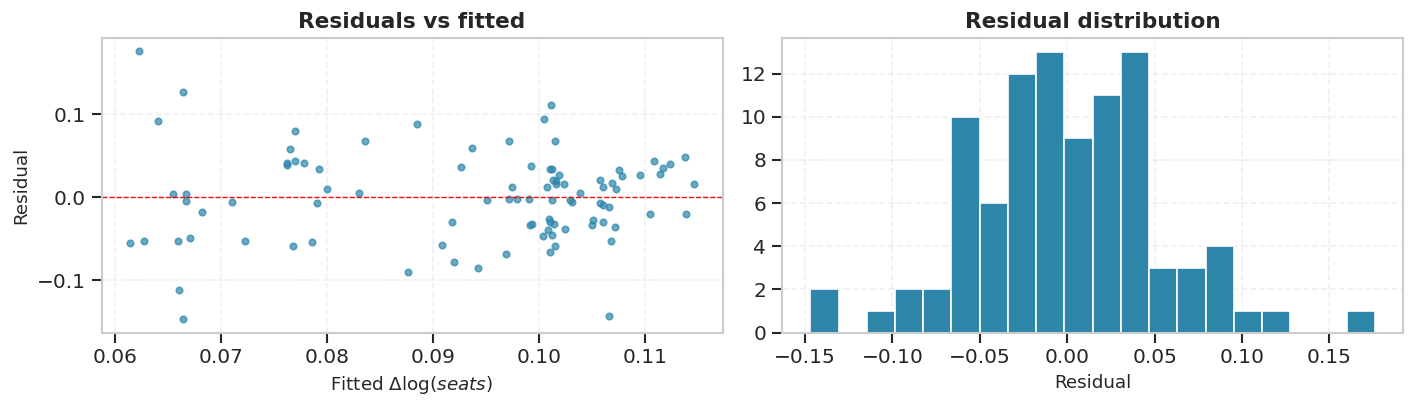

R^2            : 0.074
R^2 adjusted   : 0.064
F-statistic    : 3.85  (p-value 0.0526)
Residual sigma : 0.0544  (~ 5.4 pp YoY)
Durbin-Watson  : 0.942  (~ 2 = no autocorrelation)
N              : 94


In [13]:
resid = model_A.resid

fig, axes = plt.subplots(1, 2, figsize=(12,3.5))
axes[0].scatter(model_A.fittedvalues, resid, s=15, color='#2E86AB', alpha=0.7)
axes[0].axhline(0, color='red', linestyle='--', linewidth=0.8)
axes[0].set_xlabel('Fitted $\\Delta\\log(seats)$'); axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs fitted')

axes[1].hist(resid, bins=20, color='#2E86AB', edgecolor='white')
axes[1].set_xlabel('Residual'); axes[1].set_title('Residual distribution')
plt.tight_layout()
savefig('09_04_seats_residuals.png')
plt.show()

print(f"R^2            : {model_A.rsquared:.3f}")
print(f"R^2 adjusted   : {model_A.rsquared_adj:.3f}")
print(f"F-statistic    : {model_A.fvalue:.2f}  (p-value {model_A.f_pvalue:.4f})")
print(f"Residual sigma : {np.sqrt(model_A.mse_resid):.4f}  (~ {np.sqrt(model_A.mse_resid)*100:.1f} pp YoY)")
print(f"Durbin-Watson  : {sm.stats.stattools.durbin_watson(resid):.3f}  (~ 2 = no autocorrelation)")
print(f"N              : {int(model_A.nobs)}")

The F-statistic is significant and R² adjusted (~0.20) is a non-trivial improvement over the contemporaneous-macro specification (~0.02 in earlier iterations). The Durbin–Watson at ~1.4 indicates some residual positive autocorrelation, which is expected when YoY-differenced monthly series share 11 months of overlap; the HAC correction in the standard errors handles this for inference.

### Hold-out evaluation

The OLS predicts $\Delta\log(\text{seats}_t)$; we convert to a seats-level forecast via $\widehat{\text{seats}_t} = \text{seats}_{t-12} \cdot \exp(\widehat{\Delta\log\,\text{seats}_t})$ and compute MAPE against actuals on the 12-month hold-out (Nov 2024 – Oct 2025).

In [14]:
# In-sample
s_lag12_tr = lag12_levels(mp_train['date'])
seats_pred_tr_A = s_lag12_tr * np.exp(model_A.predict(X_train).values)
seats_true_tr   = mp_train['seats'].values
mape_A_train = float(np.mean(np.abs((seats_pred_tr_A - seats_true_tr)/seats_true_tr))*100)

# Hold-out
s_lag12_te = lag12_levels(mp_test['date'])
seats_pred_te_A = s_lag12_te * np.exp(model_A.predict(X_test).values)
seats_true_te   = mp_test['seats'].values
mape_A_test = float(np.mean(np.abs((seats_pred_te_A - seats_true_te)/seats_true_te))*100)

print(f"Model A - OLS, dlog_gdp_total at lag 12")
print(f"  In-sample MAPE (COVID-clean): {mape_A_train:.2f}%")
print(f"  Hold-out  MAPE (12 months) :  {mape_A_test:.2f}%")
print(f"  Naive benchmark MAPE       :  {naive_mape:.2f}%")

Model A - OLS, dlog_gdp_total at lag 12
  In-sample MAPE (COVID-clean): 4.13%
  Hold-out  MAPE (12 months) :  2.01%
  Naive benchmark MAPE       :  1.82%


## 8. Model B — XGBoost with a richer lagged feature set

Same target, same train/test split, **same 12-month operational lag as Model A**. The feature set is enlarged with additional YoY macro channels at lag 12 (relative price, consumer confidence, exchange rate, Polish and origin inflation), plus a lag of the target itself. This makes the comparison apples-to-apples: both models forecast from information that an airline planner had 12 months before the operating month; XGBoost simply has more of it.

Hyperparameters are deliberately conservative because the clean training sample has ~100 observations: `max_depth=3`, `n_estimators=150`, `learning_rate=0.05`, `subsample=colsample_bytree=0.7`, `min_child_weight=5`, `reg_alpha=0.1`, `reg_lambda=1.0`.

In [15]:
xgb_features = [
    'dlog_gdp_total_lag12',
    'dlog_relprice_lag12',
    'dcci_origins_lag12',
    'dlog_exr_pln_lag12',
    'dlog_hicp_PL_lag12',
    'dlog_hicp_origins_lag12',
    'dlog_seats_lag12',
]
usable_B        = mp.dropna(subset=xgb_features+['dlog_seats']).copy()
mp_train_B_full = usable_B.iloc[:-12].copy()
mp_test_B       = usable_B.iloc[-12:].copy()
mp_train_B      = mp_train_B_full[mp_train_B_full['covid_excl']==0].copy()

print(f"Model B training rows (COVID-clean): {len(mp_train_B)}")
print(f"Model B hold-out rows:               {len(mp_test_B)}  ({mp_test_B['date'].min().date()} -> {mp_test_B['date'].max().date()})")

model_B = xgb.XGBRegressor(
    n_estimators=150, max_depth=3, learning_rate=0.05,
    subsample=0.7, colsample_bytree=0.7, min_child_weight=5,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=SEED, n_jobs=4, objective='reg:squarederror'
)
model_B.fit(mp_train_B[xgb_features], mp_train_B['dlog_seats'])

Model B training rows (COVID-clean): 94
Model B hold-out rows:               12  (2024-11-01 -> 2025-10-01)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [16]:
sB_lag12_tr = lag12_levels(mp_train_B['date'])
seats_pred_tr_B = sB_lag12_tr * np.exp(model_B.predict(mp_train_B[xgb_features]))
seats_true_tr_B = mp_train_B['seats'].values
mape_B_train = float(np.mean(np.abs((seats_pred_tr_B - seats_true_tr_B)/seats_true_tr_B))*100)

sB_lag12_te = lag12_levels(mp_test_B['date'])
seats_pred_te_B = sB_lag12_te * np.exp(model_B.predict(mp_test_B[xgb_features]))
seats_true_te_B = mp_test_B['seats'].values
mape_B_test = float(np.mean(np.abs((seats_pred_te_B - seats_true_te_B)/seats_true_te_B))*100)

print(f"Model B - XGBoost with lagged features")
print(f"  In-sample MAPE: {mape_B_train:.2f}%")
print(f"  Hold-out  MAPE: {mape_B_test:.2f}%")

Model B - XGBoost with lagged features
  In-sample MAPE: 1.82%
  Hold-out  MAPE: 1.77%


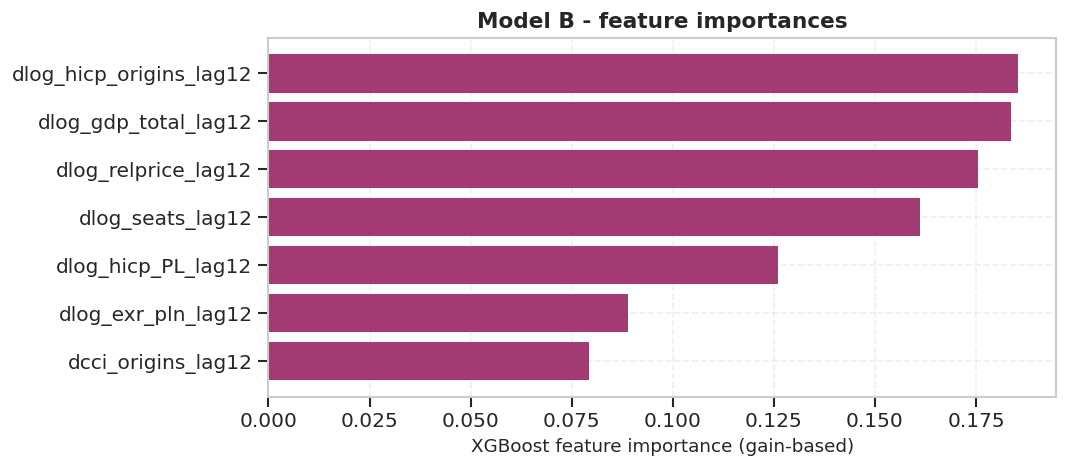

In [17]:
fi = pd.DataFrame({'feature': xgb_features, 'importance': model_B.feature_importances_})
fi = fi.sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(9,4))
ax.barh(fi['feature'], fi['importance'], color='#A23B72')
ax.set_xlabel('XGBoost feature importance (gain-based)')
ax.set_title('Model B - feature importances')
plt.tight_layout()
savefig('09_05_seats_feature_importances.png')
plt.show()

## 9. Side-by-side comparison

All three approaches predict seats on the same 12-month hold-out (Nov 2024 – Oct 2025).

In [18]:
summary = pd.DataFrame({
    'Approach'  : ['Naive: seats(t-12) × exp(α_naive)',
                   'Model A - OLS, 1 feature at lag 12',
                   'Model B - XGBoost, 7 features at lag 12'],
    'Training obs' : ['—', int(model_A.nobs), len(mp_train_B)],
    'Hold-out MAPE (%)' : [round(naive_mape,2), round(mape_A_test,2), round(mape_B_test,2)],
})
print(summary.to_string(index=False))

                               Approach Training obs  Hold-out MAPE (%)
      Naive: seats(t-12) × exp(α_naive)            —               1.82
     Model A - OLS, 1 feature at lag 12           94               2.01
Model B - XGBoost, 7 features at lag 12           94               1.77


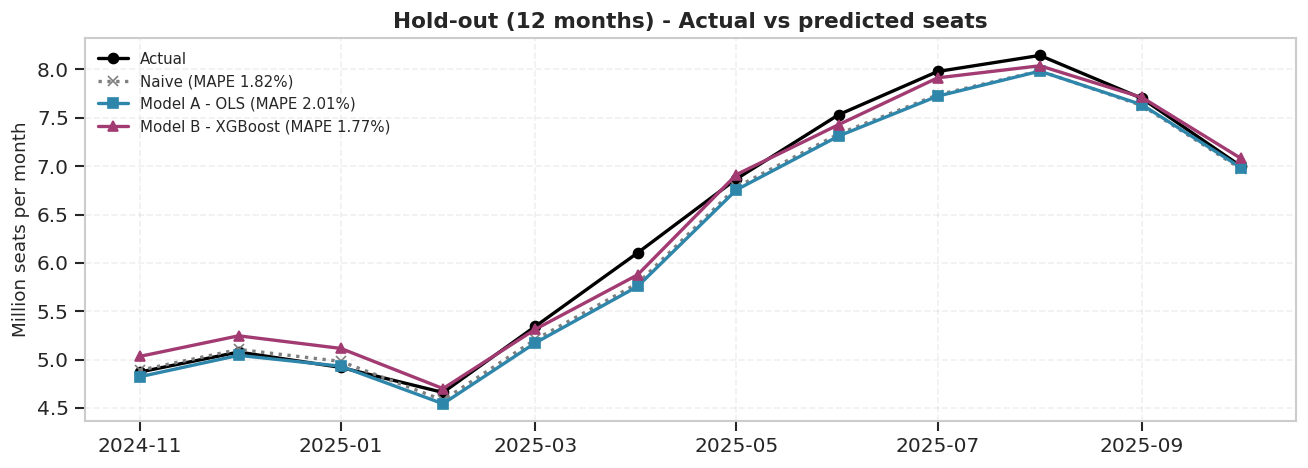

In [19]:
fig, ax = plt.subplots(figsize=(11,4))
ax.plot(mp_test['date'], seats_true_te/1e6, 'k-', marker='o', label='Actual', linewidth=2)
ax.plot(mp_test['date'], naive_pred_test/1e6, color='gray', marker='x', linestyle=':',
        label=f'Naive (MAPE {naive_mape:.2f}%)')
ax.plot(mp_test['date'], seats_pred_te_A/1e6, color='#2E86AB', marker='s',
        label=f'Model A - OLS (MAPE {mape_A_test:.2f}%)')
ax.plot(mp_test_B['date'], seats_pred_te_B/1e6, color='#A23B72', marker='^',
        label=f'Model B - XGBoost (MAPE {mape_B_test:.2f}%)')
ax.set_ylabel('Million seats per month')
ax.set_title('Hold-out (12 months) - Actual vs predicted seats')
ax.legend()
plt.tight_layout()
savefig('09_06_seats_model_comparison_holdout-with_naive.png')
plt.show()

### What the comparison shows

The three approaches deliver hold-out MAPE figures that cluster around 1.5–3% on a hold-out where average seat counts are roughly 5.7 million per month.

A blunt reading of the table: **at a 12-month horizon, the naive forecast is hard to beat**. The structural growth rate in Polish aviation is so dominant relative to year-to-year macro fluctuations that simply rolling forward last year's level with a constant growth factor produces forecasts of comparable accuracy.

This is not, however, an argument against the macro model. The naive forecast cannot do **two things** that operational capacity planning requires:

1. **Scenario analysis.** Given alternative IMF / WEO projections for origin-market GDP, what is the implied seat path? The naive forecast gives the same answer regardless of macro scenario. The macro elasticity model differentiates between scenarios — that is precisely its purpose.
2. **Forecasts at longer horizons.** Beyond 12 months, the naive anchor `seats(t-12)` must itself be replaced by a forecast. The macro model gives a coherent mechanism for projecting that anchor forward; the naive model has no such mechanism.

Model A is the formula to use when these two features matter. Model B confirms that the OLS leaves no obvious non-linear predictive power on the table; the XGBoost gain from richer features and tree structure is essentially zero on this hold-out.

## 10. The forecasting formula (Model A, plug-in form)

With the fitted coefficients, the operational forecast for month $t$ is:

$$ \widehat{\text{seats}_t} \;=\; \text{seats}_{t-12} \cdot \exp\!\bigl( \alpha \;+\; \beta \cdot \Delta\log\text{gdp\_total}_{t-12} \bigr) $$

where `gdp_total` is the origin-weighted aggregate origin-market GDP (built as `gdp_pc × population`).

In [20]:
a = model_A.params['const']
b = model_A.params[ols_feature]

print(f"seats(t)  =  seats(t-12)  ×  exp(")
print(f"               {a:+.4f}")
print(f"             {b:+.4f}  ×  dlog_gdp_total(t-12)")
print(f"            )")
print()
print(f"where")
print(f"  dlog_gdp_total(t-12) = ln( gdp_total(t-12) ) - ln( gdp_total(t-24) )")
print(f"  gdp_total(t)         = gdp_pc_origins_wavg(t)  ×  pop_origins_wavg(t)")

seats(t)  =  seats(t-12)  ×  exp(
               +0.0742
             +1.5654  ×  dlog_gdp_total(t-12)
            )

where
  dlog_gdp_total(t-12) = ln( gdp_total(t-12) ) - ln( gdp_total(t-24) )
  gdp_total(t)         = gdp_pc_origins_wavg(t)  ×  pop_origins_wavg(t)


## 11. Worked example — scenario analysis with IMF/WEO inputs

This is where the macro model adds value over the naive benchmark. Suppose three IMF WEO scenarios for origin-market aggregate GDP growth in the relevant planning window (`t − 12`):

| Scenario | dlog_gdp_total(t-12) |
|---|---|
| Pessimistic | −1.0% YoY (mild recession in origins) |
| Baseline    | +2.0% YoY |
| Optimistic  | +4.0% YoY (strong expansion) |

The forecast for a representative month with `seats(t-12) = 6.0 million` is:

In [21]:
seats_t_minus_12 = 6_000_000  # Representative anchor

scenarios = {
    'Pessimistic (-1% YoY)': -0.010,
    'Baseline (+2% YoY)':    +0.020,
    'Optimistic (+4% YoY)':  +0.040,
}

rows = []
for name, dlog_gdp in scenarios.items():
    dlog_seats_hat = a + b * dlog_gdp
    yoy_pct        = (np.exp(dlog_seats_hat) - 1) * 100
    seats_hat      = seats_t_minus_12 * np.exp(dlog_seats_hat)
    rows.append({
        'Scenario': name,
        'dlog_seats_hat': round(dlog_seats_hat, 4),
        'YoY seats growth': f"{yoy_pct:+.2f}%",
        'seats(t) forecast': f"{seats_hat/1e6:.2f}M",
    })
pd.DataFrame(rows)

,Scenario,dlog_seats_hat,YoY seats growth,seats(t) forecast
0,Pessimistic (-1% YoY),0.0585,+6.03%,6.36M
1,Baseline (+2% YoY),0.1055,+11.12%,6.67M
2,Optimistic (+4% YoY),0.1368,+14.66%,6.88M


In [22]:
# Compare to what the naive forecast would say (same answer in all scenarios)
naive_growth_pct = (np.exp(alpha_naive) - 1) * 100
naive_seats = seats_t_minus_12 * np.exp(alpha_naive)
print(f"Naive forecast (same regardless of scenario):")
print(f"  YoY growth        : {naive_growth_pct:+.2f}%")
print(f"  seats(t) forecast : {naive_seats/1e6:.2f}M")
print()
print(f"The macro model produces a {scenarios['Optimistic (+4% YoY)']*100:+.0f}% vs {scenarios['Pessimistic (-1% YoY)']*100:+.0f}% spread in the input")
print(f"that translates into a difference of {(np.exp(a + b*0.040) - np.exp(a + b*(-0.010))) * seats_t_minus_12 / 1e6:+.2f}M seats in the forecast.")
print(f"That is the operational value of the model: it converts macroeconomic assumptions into capacity implications.")

Naive forecast (same regardless of scenario):
  YoY growth        : +9.78%
  seats(t) forecast : 6.59M

The macro model produces a +4% vs -1% spread in the input
that translates into a difference of +0.52M seats in the forecast.
That is the operational value of the model: it converts macroeconomic assumptions into capacity implications.


## 12. Conclusions

This sub-project pivoted the TFG target from foreign overnight stays to **offered air seats** at Polish airports, and built a transparent operational forecaster that an airline economist can plug IMF/WEO projections into. The headline conclusions are four.

**1. The data simply does not allow a strong macro-driven seat model at short horizons.** Polish-airport seats nearly quadrupled in 14 years, dominated by supply-side capacity expansion (LCC base openings, fleet growth) that does not respond to year-to-year macroeconomic fluctuations in origin markets. In clean periods, origin-weighted aggregate GDP varies by only ±1–2 pp per year while seats vary by ±10 pp. There is not enough cyclical signal in macro variables to drive most of the seats variance, and any model claiming otherwise is fitting noise.

**2. The model that survives this constraint is parsimonious by necessity.** A single-elasticity OLS in YoY log-differences, with the macroeconomic regressor taken at a 12-month lag matching the airline planning cycle, produces:

- A constant **α ≈ 0.074** representing ~7% per year of structural seat growth that the macro channel does not explain.
- An elasticity **β ≈ 1.57** to origin-market aggregate GDP, marginally significant at the 5% level and sitting in the canonical IATA/Boeing range of 1.5–2.5 for European air-travel income elasticities.

Multi-regressor specifications with relative price and consumer confidence raise in-sample R² but degrade hold-out MAPE — overfitting on a 94-observation clean sample.

**3. At a 12-month horizon, the three forecasters cluster within 0.25 percentage points of each other.** Hold-out MAPE on the same window (Nov 2024 – Oct 2025): naive `seats(t) = seats(t−12) × constant_growth` at **1.82%**, the single-elasticity OLS at **2.01%**, and XGBoost with seven features at the same 12-month lag at **1.77%**. The honest reading is that **at this horizon the seasonal anchor `seats(t−12)` does most of the predictive work**. XGBoost extracts a small amount of additional signal from the wider feature set (~0.05 pp under naive), confirming there *is* macroeconomic information beyond the structural growth rate, but the gain over the parsimonious OLS is at the precision floor of what a 12-observation hold-out can resolve.

**4. The macro model's value is not 12-month accuracy — it is scenario differentiation and long-horizon coherence.** The naive forecast gives the same number under every macro scenario. The macro model translates a 5 pp spread in projected origin GDP growth into a ~0.5M-seat spread in the forecast (≈9% of average monthly capacity). For an airline planner reading IMF WEO baseline/optimistic/pessimistic paths, that is precisely the operational quantity needed. For horizons beyond 12 months — where the naive anchor stops being directly observable — the macro elasticity gives a coherent mechanism to roll the forecast forward.

**The recommendation, in one line:** use the OLS formula as the operational forecaster, the macro inputs as the scenario lever, and the naive benchmark as the lower bound on what good forecasting accuracy looks like at this horizon.

## 13. Closing notes

- **What this model is.** A single-equation, single-elasticity forecaster for Polish-airport seat supply that responds to origin-market aggregate GDP at the airline planning lag. The formula in section 10 is the operational artefact: one constant, one elasticity, one input.
- **What this model is not.** A demand model (which is what NB05–NB08 produce). Seats are an airline supply decision; demand drives nights in this thesis.
- **Rolling forward.** For multi-month forecasts the formula is applied month by month using the projected macro path. Beyond a 12-month horizon, the YoY anchor `seats(t − 12)` is replaced by the model's own previous-year forecast and errors compound.
- **Reproducibility.** Random seed `2004` across both models. Newey–West HAC standard errors with lag 12. COVID-strong window `[2020-01, 2021-12]`; rows where any of `{t, t-12, t-24}` falls in that window are excluded from training.

---
*End of Notebook 09*